In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
random.seed = 5

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


<AxesSubplot:xlabel='age', ylabel='Density'>

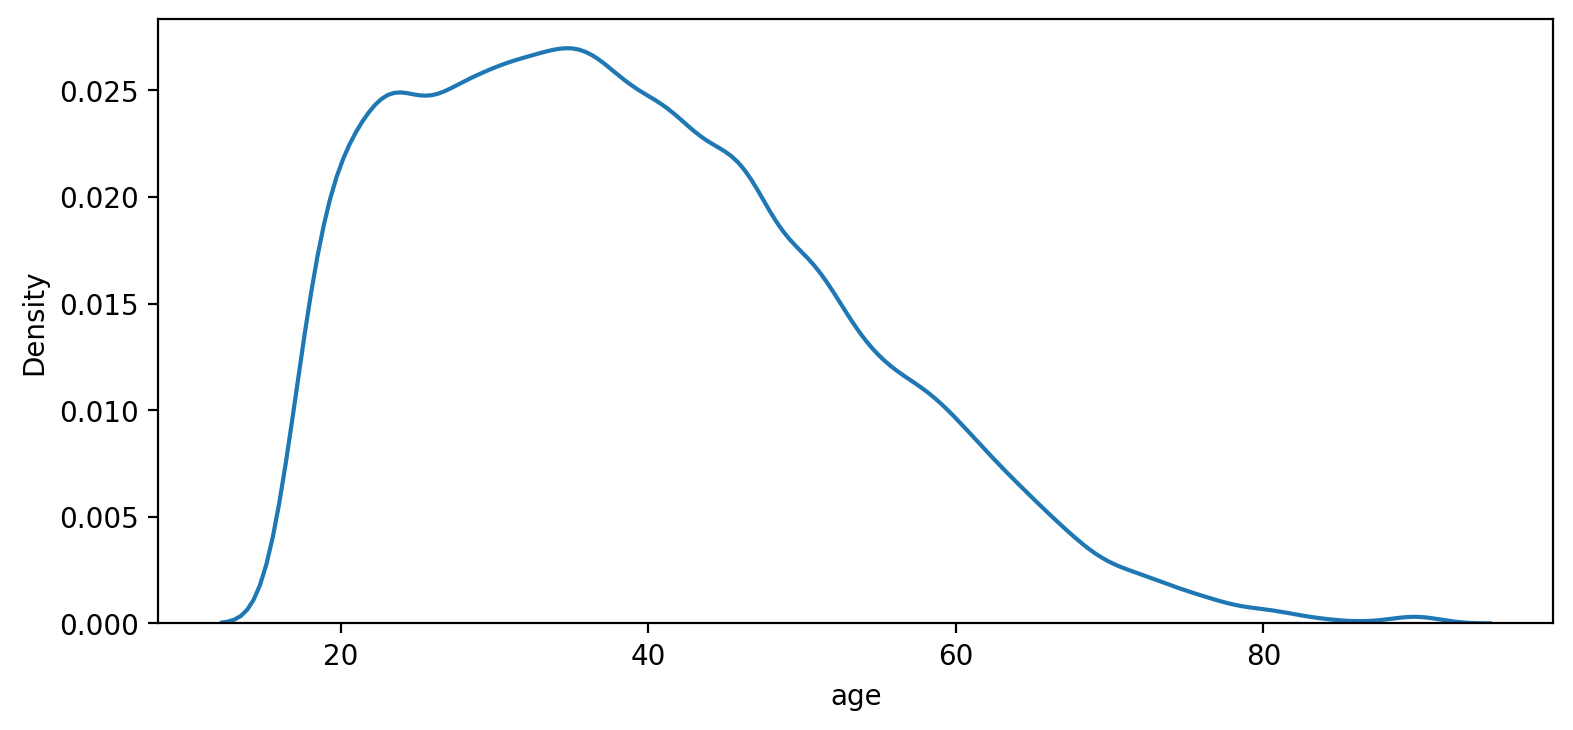

In [30]:
plt.figure(figsize = (9,4),dpi = 200)
sns.distplot(df.age, hist = False)

In [7]:
print('Number of rows (Observations) : ', df.shape[0])

Number of rows (Observations) :  48842


In [10]:
samples = random.sample(range(0,df.shape[0]),50)

In [11]:
samples

[38283,
 29553,
 2235,
 25495,
 2564,
 46766,
 47185,
 35444,
 14513,
 29996,
 23195,
 6870,
 21571,
 14095,
 4638,
 5944,
 10883,
 7269,
 12267,
 21035,
 26899,
 36581,
 9290,
 13564,
 9149,
 9304,
 33061,
 9163,
 12270,
 33664,
 4271,
 8121,
 16433,
 3838,
 33622,
 300,
 16643,
 35346,
 1039,
 4772,
 13601,
 7743,
 39498,
 22977,
 15741,
 2110,
 34995,
 14684,
 13046,
 14143]

In [22]:
df.iloc[samples,0]

38283    32
29553    36
2235     48
25495    24
2564     30
46766    46
47185    22
35444    19
14513    50
29996    20
23195    67
6870     21
21571    47
14095    41
4638     29
5944     55
10883    65
7269     46
12267    34
21035    50
26899    53
36581    41
9290     32
13564    34
9149     31
9304     55
33061    37
9163     58
12270    43
33664    17
4271     32
8121     45
16433    33
3838     32
33622    43
300      39
16643    43
35346    31
1039     24
4772     42
13601    33
7743     18
39498    22
22977    22
15741    50
2110     50
34995    28
14684    59
13046    68
14143    53
Name: age, dtype: int64

In [23]:
df.iloc[samples,0].mean()

39.0

In [25]:
sample_means = {}
means = []
for i in range(500):
    samples = random.sample(range(0,df.shape[0]),50)
    means.append(df.iloc[samples,0].mean())
    
sample_means['500samp_50size'] = means

<AxesSubplot:ylabel='Density'>

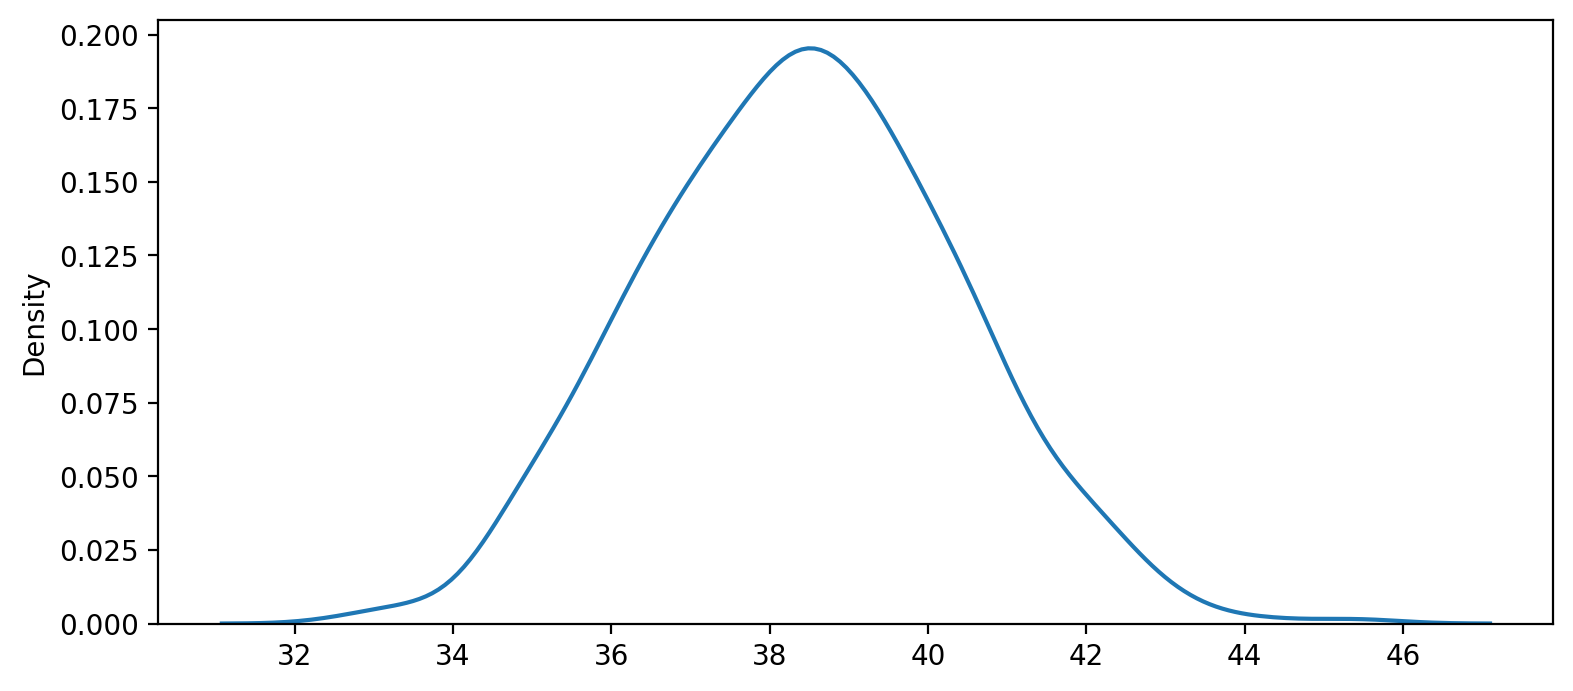

In [27]:
plt.figure(figsize = (9,4),dpi = 200)
sns.distplot(sample_means['500samp_50size'], hist = False)

### We can see the sample means are normally distributed

In [32]:
# Mean of sample means is approximately equal to population mean
mean_of_samples = np.mean(sample_means['500samp_50size'])
population_mean = df.age.mean()

print('Mean of sample means : ', mean_of_samples)
print('Mean of Population   : ', population_mean)

Mean of sample means :  38.41664
Mean of Population   :  38.64358543876172


In [33]:
# Standard Deviation of samples is approximately equal to (std of population/sqrt(sample size))
std_of_sample = np.std(sample_means['500samp_50size'])
calculated_std = df.age.std()/np.sqrt(50)

print('Calculated standard deviation : ', calculated_std)
print('Actual Standard deviation     : ', std_of_sample)

Calculated standard deviation :  1.9389589096341133
Actual Standard deviation     :  1.959572991853072


# ---------------------------------------------------------------------------------------

### Understanding the effcet of increase in sample sizes and number of samples

In [34]:
def calc_sample_means(n_samples, sample_size):
    means = []
    for i in range(n_samples):
        samples = random.sample(range(0,df.shape[0]),sample_size)
        means.append(df.iloc[samples,0].mean())
        
    return means

In [35]:
sample_means = {}

sample_means['10samp_50size']     = calc_sample_means(10,50)
sample_means['100samp_50size']    = calc_sample_means(100,50)
sample_means['1000samp_50size']   = calc_sample_means(1000,50)
sample_means['10samp_100size']    = calc_sample_means(10,100)
sample_means['100samp_100size']   = calc_sample_means(100,100)
sample_means['1000samp_100size']  = calc_sample_means(1000,100)
sample_means['10samp_1000size']   = calc_sample_means(10,1000)
sample_means['100samp_1000size']  = calc_sample_means(100,1000)
sample_means['1000samp_1000size'] = calc_sample_means(1000,1000)

In [36]:
data = list(sample_means.items())

In [37]:
plt.figure(figsize = (16,16),dpi = 1000)
for i in range(9):
    plt.subplot(3,3,i+1) 
    sns.distplot(data[i][1],hist = False)
    plt.title(label = data[i][0])

In [38]:
print('Population Mean : ', df.age.mean())
for i,j in sample_means.items():
    print('Mean for {} is :'.format(i), np.mean(j))

Population Mean :  38.64358543876172
Mean for 10samp_50size is : 38.907999999999994
Mean for 100samp_50size is : 38.672999999999995
Mean for 1000samp_50size is : 38.69672
Mean for 10samp_100size is : 38.024
Mean for 100samp_100size is : 38.9334
Mean for 1000samp_100size is : 38.61825000000001
Mean for 10samp_1000size is : 38.752100000000006
Mean for 100samp_1000size is : 38.66308
Mean for 1000samp_1000size is : 38.63401


In [39]:
pop_std = df.age.std()
print('Population STD : ', pop_std)
print('Calculated STD Sample size = 50   : ',pop_std/ 50**0.5)
print('Calculated STD Sample size = 100  : ',pop_std/ 100**0.5)
print('Calculated STD Sample size = 1000 : ',pop_std/ 1000**0.5)

Population STD :  13.710509934443557
Calculated STD Sample size = 50   :  1.9389589096341133
Calculated STD Sample size = 100  :  1.3710509934443558
Calculated STD Sample size = 1000 :  0.4335643927520749


In [40]:
print('Actual STD for Smaple size 50   : ',np.std(list(sample_means.items())[1][1]))
print('Actual STD for Smaple size 100  : ',np.std(list(sample_means.items())[5][1]))
print('Actual STD for Smaple size 1000 : ',np.std(list(sample_means.items())[8][1]))

Actual STD for Smaple size 50   :  1.9081496272567304
Actual STD for Smaple size 100  :  1.3798981982378267
Actual STD for Smaple size 1000 :  0.43872858796754977
